# 🧠 PEFT, LoRA ve QLoRA Uygulamaları
## Büyük Dil Modellerini Lambda Labs GPU Bulutunda Verimli Şekilde İnce Ayarlamak

Bu defter (notebook), büyük dil modellerini (LLM) **Parametre-Etkin İnce Ayar (PEFT)**
yöntemleriyle, özellikle **LoRA** ve **QLoRA** teknikleriyle, **Lambda Labs** GPU bulut
altyapısı üzerinde nasıl ince ayar (fine-tuning) yapacağınızı adım adım, matematiksel
temelleriyle, görsel diyagramlarla ve gerçek kod örnekleriyle anlatır.

> **Not — Çalıştırma hakkında:** Bu defterdeki diyagram ve kavram-ispatı (proof-of-concept)
> hücreleri zaten çalıştırılmış ve çıktıları gömülüdür; bunları herhangi bir bilgisayarda
> (GPU gerekmeden) tekrar çalıştırabilirsiniz. **Gerçek model yükleme, 4-bit kuantizasyon ve
> eğitim hücreleri ise bir GPU (örn. Lambda Labs'te kiralanan bir A100/H100 instance'ı)
> gerektirir** ve bu defterde kasıtlı olarak çalıştırılmamış halde bırakılmıştır — onları
> Lambda Labs üzerinde açtığınız bir Jupyter ortamında çalıştırmanız beklenir.

---

### 📑 İçindekiler

1. [Giriş: Neden PEFT?](#1)
2. [Lambda Labs Üzerinde Ortam Kurulumu](#2)
3. [LoRA'ya Derinlemesine Bakış](#3)
4. [Hugging Face PEFT Kütüphanesi ile LoRA](#4)
5. [QLoRA: Kuantize Edilmiş LoRA](#5)
6. [Eğitim: TRL SFTTrainer ile Uçtan Uca Fine-Tuning](#6)
7. [Adaptör Birleştirme (Merge) ve Çıkarım (Inference)](#7)
8. [Lambda Labs'e Özgü İpuçları ve Çoklu-GPU Eğitimi](#8)
9. [Karar Rehberi: Hangi Yöntemi Ne Zaman Kullanmalı?](#9)
10. [Kaynaklar](#10)


<a id="1"></a>
## 1. Giriş: Neden PEFT?

Büyük dil modelleri (LLM) milyarlarca parametreden oluşur. Bir modeli **tam ince ayar**
(full fine-tuning) ile eğitmek istediğinizde, GPU belleğinde şunları aynı anda tutmanız
gerekir:

| Bileşen | Tipik Boyut (mixed-precision AdamW ile) |
|---|---|
| Model ağırlıkları (FP16/BF16) | 2 byte / parametre |
| Gradyanlar (FP16/BF16) | 2 byte / parametre |
| Optimizer momentum + varyans (Adam, FP32) | 8 byte / parametre |
| Karışık hassasiyet için FP32 "master" ağırlık kopyası | 4 byte / parametre |
| **Toplam** | **~16 byte / parametre** |

Bu, **7 milyar (7B) parametreli** sıradan bir açık kaynak modeli için yaklaşık
**112 GB** bellek anlamına gelir — ve bu hesap, aktivasyonların (forward pass'te
ara katman çıktılarının) kapladığı belleği bile içermez! Tek bir GPU'ya (en güçlü
tüketici/iş istasyonu kartları dahi 24-48GB'tır) bu modelin tamamını eğitmek için
sığmanız mümkün değildir; büyük modellerde bu rakam 70B+ parametre için TB seviyesine çıkar.

**Parametre-Etkin İnce Ayar (Parameter-Efficient Fine-Tuning, PEFT)**, bu soruna zarif bir
çözüm sunar: **önceden eğitilmiş modelin ağırlıklarının tamamını dondurup (frozen)**,
yalnızca **küçük, ek bir parametre kümesini** eğitilebilir bırakır. Bu sayede:

- Eğitilebilir parametre sayısı, toplam parametrelerin genellikle %0.1 - %1'i kadardır.
- GPU bellek ihtiyacı drastik şekilde düşer (gradyan ve optimizer durumu sadece küçük
  ek parametreler için tutulur).
- Aynı taban modele birden çok görev için birden çok küçük "adaptör" eğitilip
  saklanabilir (her biri genellikle yalnızca birkaç on/yüz MB).
- Modelin orijinal genel yetenekleri büyük ölçüde korunur ("catastrophic forgetting"
  riski azalır), çünkü taban ağırlıklar hiç değişmez.

Aşağıdaki grafikler bu farkı somut biçimde gösteriyor:


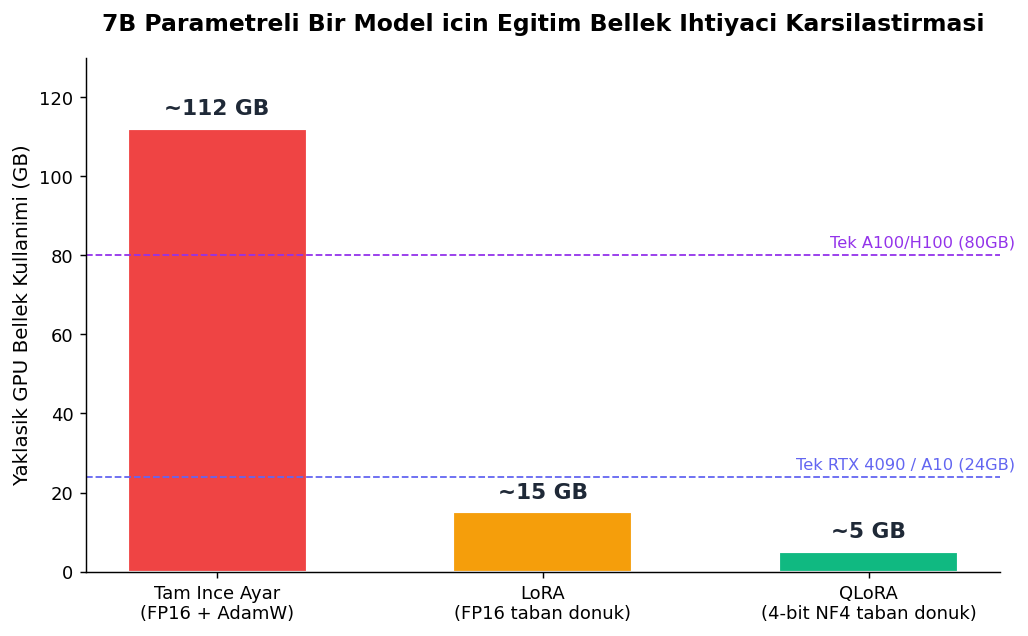

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 7 milyar (7B) parametreli bir dil modeli icin YAKLASIK GPU bellek ihtiyaci.
# Not: Bu sayilar egitim sirasindaki aktivasyon bellegini DAHIL ETMEZ;
# sadece agirlik + gradyan + optimizer durumu bellegini gosterir.
yontemler = ["Tam Ince Ayar\n(FP16 + AdamW)", "LoRA\n(FP16 taban donuk)", "QLoRA\n(4-bit NF4 taban donuk)"]
bellek_gb = [112, 15, 5]
renkler = ["#ef4444", "#f59e0b", "#10b981"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(yontemler, bellek_gb, color=renkler, edgecolor="white", linewidth=1.2, width=0.55)

for bar, deger in zip(bars, bellek_gb):
    ax.text(bar.get_x() + bar.get_width()/2, deger + 2.5, f"~{deger} GB",
            ha="center", va="bottom", fontsize=12, fontweight="bold", color="#1f2937")

ax.set_ylabel("Yaklasik GPU Bellek Kullanimi (GB)", fontsize=11)
ax.set_title("7B Parametreli Bir Model icin Egitim Bellek Ihtiyaci Karsilastirmasi", fontsize=13, fontweight="bold", pad=15)
ax.set_ylim(0, 130)
ax.axhline(24, color="#6366f1", linestyle="--", linewidth=1)
ax.text(2.45, 26, "Tek RTX 4090 / A10 (24GB)", color="#6366f1", fontsize=9, ha="right")
ax.axhline(80, color="#9333ea", linestyle="--", linewidth=1)
ax.text(2.45, 82, "Tek A100/H100 (80GB)", color="#9333ea", fontsize=9, ha="right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


Dikkat ederseniz **LoRA** (taban model 16-bit hassasiyette belleğe yüklenir) ile
**QLoRA** (taban model 4-bit'e kuantize edilerek yüklenir) arasındaki bellek farkı da
oldukça büyük — bu sayede QLoRA, 7B'lik bir modeli tek bir 24GB'lık tüketici GPU'sunda
(örn. RTX 4090) bile eğitilebilir hale getirir.

Aynı tabloyu eğitilebilir parametre sayısı açısından da görelim:


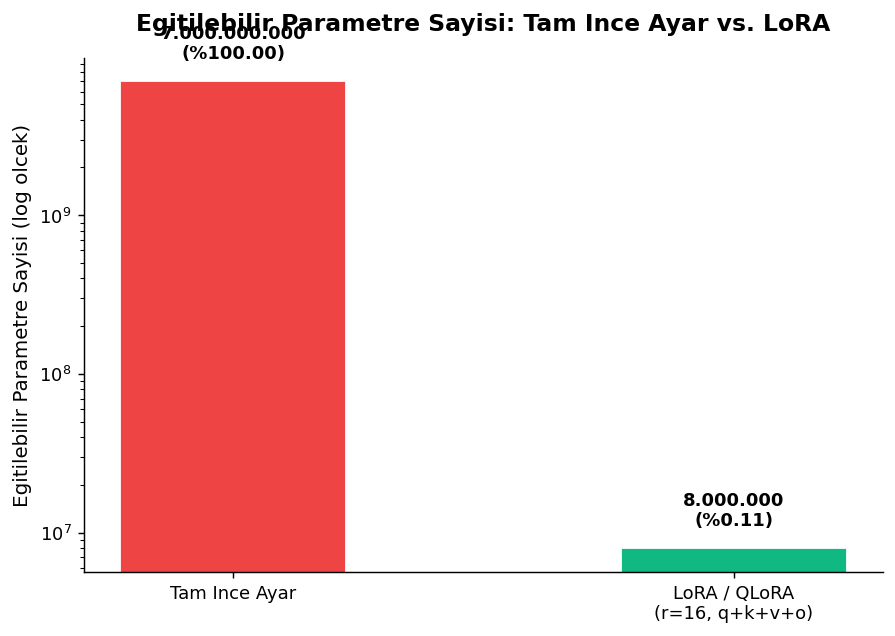

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Egitilebilir parametre sayisi karsilastirmasi (logaritmik eksen)
yontemler = ["Tam Ince Ayar", "LoRA / QLoRA\n(r=16, q+k+v+o)"]
toplam_param = 7_000_000_000
lora_param = 8_000_000  # tipik LoRA adaptor parametre sayisi (~%0.11)
degerler = [toplam_param, lora_param]
yuzdeler = [100.0, lora_param/toplam_param*100]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(yontemler, degerler, color=["#ef4444", "#10b981"], width=0.45, edgecolor="white")
ax.set_yscale("log")
ax.set_ylabel("Egitilebilir Parametre Sayisi (log olcek)", fontsize=11)
ax.set_title("Egitilebilir Parametre Sayisi: Tam Ince Ayar vs. LoRA", fontsize=13, fontweight="bold", pad=15)

for bar, deger, yuzde in zip(bars, degerler, yuzdeler):
    ax.text(bar.get_x() + bar.get_width()/2, deger*1.3,
            f"{deger:,}\n(%{yuzde:.2f})".replace(",", "."),
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### PEFT Yöntemleri Ailesi

LoRA, PEFT şemsiyesi altındaki en popüler yöntemdir ama tek yöntem değildir. Kısaca
karşılaştıralım:

| Yöntem | Temel Fikir | Tipik Kullanım |
|---|---|---|
| **LoRA** | Ağırlık güncellemesini düşük-ranklı B·A matris çarpımıyla yaklaşıklar | En yaygın, dengeli performans/verimlilik |
| **QLoRA** | LoRA + taban modelin 4-bit (NF4) kuantizasyonu | Çok büyük modelleri tek GPU'da eğitmek için |
| **Prefix Tuning** | Her katmanın dikkat (attention) girdisine eğitilebilir "sanal token"lar ekler | Üretim (generation) görevlerinde iyi |
| **Prompt Tuning** | Sadece girdi embedding katmanına eğitilebilir "soft prompt" ekler | Çok büyük modellerde bile çok az parametre |
| **(IA)³** | Aktivasyonları öğrenilen vektörlerle ölçekler (çarpar) | LoRA'dan da az parametre, hafif görevler |
| **AdaLoRA** | LoRA rank'ini eğitim sırasında katman önemine göre dinamik ayarlar | Sabit rank seçmek istemediğinizde |
| **BitFit** | Sadece bias terimlerini eğitir | Çok hafif, sınırlı kapasite |

Bu defterde özellikle **LoRA** ve **QLoRA**'ya odaklanıyoruz, çünkü pratikte en yaygın
kullanılan, en olgun kütüphane desteğine sahip ve en iyi performans/verimlilik dengesini
sunan yöntemlerdir.


<a id="2"></a>
## 2. Lambda Labs Üzerinde Ortam Kurulumu

[Lambda Labs](https://lambda.ai), özellikle derin öğrenme iş yükleri için optimize edilmiş
GPU bulut sunucuları sağlayan bir platformdur. Bu bölümde bir Lambda Labs instance'ı nasıl
seçilir, nasıl başlatılır ve PEFT/LoRA/QLoRA için gerekli kütüphaneler nasıl kurulur, adım
adım anlatılmaktadır.

### 2.1 Model Büyüklüğüne Göre GPU Seçimi

Aşağıdaki tablo, farklı model büyüklükleri için **kabaca** hangi GPU'nun yeterli olacağını
özetler. Buradaki VRAM rakamları teknik özellik (sabit gerçekler) olduğu için güvenilirdir;
ancak **fiyatlar sürekli değiştiği için yalnızca yaklaşık/gösterge niteliğindedir** — güncel
fiyatlandırma için her zaman [lambda.ai/pricing](https://lambda.ai/pricing) sayfasını kontrol edin.

| Model Boyutu | Yöntem | Önerilen GPU | VRAM | Yaklaşık Saatlik Fiyat* |
|---|---|---|---|---|
| 7B | QLoRA | 1x A10 / RTX 6000 Ada | 24 GB | ~$0.5 - $1.0/sa |
| 7B | LoRA (bf16) | 1x A100 40GB | 40 GB | ~$1.0 - $1.5/sa |
| 13B | QLoRA | 1x A100 40GB | 40 GB | ~$1.0 - $1.5/sa |
| 13B | LoRA (bf16) | 1x A100 80GB / H100 | 80 GB | ~$1.5 - $3.0/sa |
| 70B | QLoRA | 1-2x A100 80GB / H100 | 80-160 GB | ~$2.0 - $6.0/sa |
| 70B | LoRA (bf16) | 4x A100 80GB / H100 | 320 GB | ~$6.0 - $15/sa |

> ⚠️ **Önemli:** Yukarıdaki fiyatlar yalnızca **gösterge niteliğindedir** ve yazım anına göre
> büyük ölçüde değişebilir; Lambda Labs fiyatları zaman zaman güncellenmektedir. Gerçek bir
> instance kiralamadan önce her zaman güncel fiyat sayfasını kontrol edin. Lambda Labs;
> dakika bazlı faturalandırma, sıfır "egress" (veri çıkış) ücreti ve önceden kurulu
> "Lambda Stack" (Ubuntu + CUDA + cuDNN + PyTorch + TensorFlow) sunar; bu da kurulum süresini
> önemli ölçüde azaltır.

### 2.2 Instance Başlatma Adımları

1. [cloud.lambda.ai](https://cloud.lambda.ai) adresinden hesabınıza giriş yapın.
2. **"Launch Instance"** butonuna tıklayın, yukarıdaki tabloya göre bir GPU tipi seçin.
3. Bir SSH anahtarı (key pair) seçin veya yeni bir anahtar oluşturun.
4. Bölge (region) seçin — genellikle stoğu en uygun olan bölgeyi otomatik önerir.
5. Instance ayağa kalktığında, Lambda Labs dashboard'undan **doğrudan tek-tıkla Jupyter
   erişimi** sağlanır (ayrıca SSH ile de bağlanabilirsiniz).
6. Jupyter arayüzü açıldığında bu defteri (.ipynb dosyasını) yükleyip kaldığınız yerden
   devam edebilirsiniz.

### 2.3 Gerekli Kütüphanelerin Kurulumu

Lambda Stack PyTorch'u önceden kurulu getirir, ancak PEFT ekosistemi için ek kütüphaneler
gerekir. Instance'a bağlandıktan sonra aşağıdaki hücreyi çalıştırın:


In [ ]:
# Bu hücre Lambda Labs GPU instance'ında çalıştırılmalıdır (bu defterde kasıtlı olarak
# çalıştırılmamıştır çünkü bu ortamda GPU ve internet erişimi (huggingface.co) yoktur).

!pip install -q -U transformers accelerate peft bitsandbytes datasets trl

# Sürüm önerisi (yazım tarihi itibarıyla uyumlu, projenize göre güncelleyin):
#   transformers >= 4.44
#   peft         >= 0.12
#   bitsandbytes >= 0.43   (QLoRA için CUDA gerektirir)
#   trl          >= 0.10
#   accelerate   >= 0.33


### 2.4 GPU'nun Doğrulanması

Kurulumdan sonra GPU'nun gerçekten görünür ve kullanılabilir olduğunu doğrulayın:


In [ ]:
# Lambda Labs instance'ında çalıştırın:
import torch

print("CUDA kullanılabilir mi?", torch.cuda.is_available())
print("Görünen GPU sayısı     :", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU adı                :", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"Toplam VRAM            : {props.total_memory / 1024**3:.1f} GB")

!nvidia-smi


<a id="3"></a>
## 3. LoRA'ya Derinlemesine Bakış

**LoRA (Low-Rank Adaptation)**, 2021'de Hu ve arkadaşları tarafından önerilen bir PEFT
yöntemidir (arXiv:2106.09685). Temel fikir şudur: ince ayar sırasında bir ağırlık matrisine
($W_0 \in \mathbb{R}^{d_{in} \times d_{out}}$) yapılan güncelleme ($\Delta W$) genellikle
**düşük-ranklı (low-rank)** bir yapıya sahiptir — yani $\Delta W$'yi, boyutu çok daha küçük
iki matrisin çarpımı olarak yaklaşıklayabiliriz.

### 3.1 Matematiksel Formülasyon

$$W' = W_0 + \Delta W = W_0 + \frac{\alpha}{r} \, B \, A$$

Burada:
- $W_0$: önceden eğitilmiş, **donuk (frozen)** taban ağırlık matrisi — eğitim sırasında
  **hiç güncellenmez**.
- $B \in \mathbb{R}^{d_{in} \times r}$ ve $A \in \mathbb{R}^{r \times d_{out}}$: yeni eklenen,
  **eğitilebilir** düşük-rank matrisler.
- $r$: **rank** — genellikle 4 ile 64 arasında küçük bir sayı ($r \ll \min(d_{in}, d_{out})$).
- $\alpha$: **lora_alpha** — ölçekleme (scaling) katsayısı; $\Delta W$'nin etkisinin büyüklüğünü
  kontrol eder. $\alpha/r$ oranı, öğrenme oranıyla birlikte etkin öğrenme hızını belirler.

**Başlatma kuralı çok önemlidir:** $B$ matrisi **sıfırlarla** başlatılır, $A$ matrisi ise
küçük rastgele değerlerle. Bu sayede eğitim başında $\Delta W = B \cdot A = 0$ olur, yani
model, eğitime **tam olarak önceden eğitilmiş haliyle** başlar — hiçbir ani performans
kaybı veya bozulma olmaz.

Aşağıdaki diyagram bu ayrıştırmayı görsel olarak özetliyor:


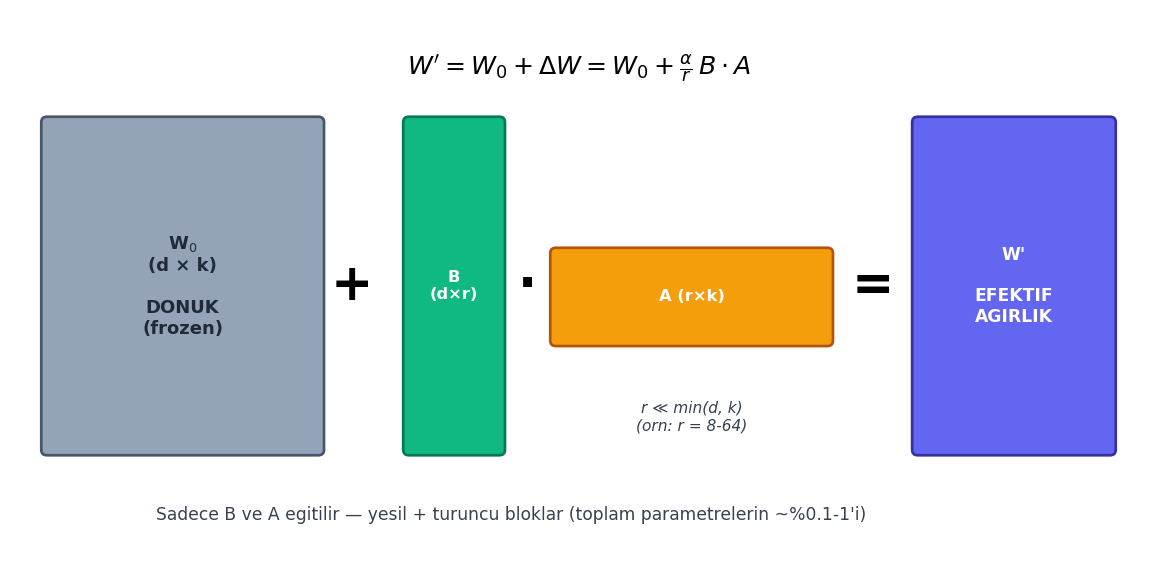

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

# W0 - donuk (frozen) agirlik matrisi
w0 = mpatches.FancyBboxPatch((0.3, 1), 2.4, 3, boxstyle="round,pad=0.05",
                              facecolor="#94a3b8", edgecolor="#475569", linewidth=1.5)
ax.add_patch(w0)
ax.text(1.5, 2.5, "W$_0$\n(d × k)\n\nDONUK\n(frozen)", ha="center", va="center", fontsize=10, fontweight="bold", color="#1f2937")

ax.text(3.0, 2.5, "+", ha="center", va="center", fontsize=28, fontweight="bold")

# B matrisi (d x r) - uzun ince
b_mat = mpatches.FancyBboxPatch((3.5, 1), 0.8, 3, boxstyle="round,pad=0.05",
                                 facecolor="#10b981", edgecolor="#047857", linewidth=1.5)
ax.add_patch(b_mat)
ax.text(3.9, 2.5, "B\n(d×r)", ha="center", va="center", fontsize=9, fontweight="bold", color="white")

ax.text(4.55, 2.5, "·", ha="center", va="center", fontsize=28, fontweight="bold")

# A matrisi (r x k) - kisa genis
a_mat = mpatches.FancyBboxPatch((4.8, 2.0), 2.4, 0.8, boxstyle="round,pad=0.05",
                                 facecolor="#f59e0b", edgecolor="#b45309", linewidth=1.5)
ax.add_patch(a_mat)
ax.text(6.0, 2.4, "A (r×k)", ha="center", va="center", fontsize=9, fontweight="bold", color="white")

ax.text(6.0, 1.3, "r ≪ min(d, k)\n(orn: r = 8-64)", ha="center", va="center", fontsize=8.5, style="italic", color="#374151")

ax.text(7.6, 2.5, "=", ha="center", va="center", fontsize=28, fontweight="bold")

# W' sonuc matrisi
w_prime = mpatches.FancyBboxPatch((8.0, 1), 1.7, 3, boxstyle="round,pad=0.05",
                                   facecolor="#6366f1", edgecolor="#3730a3", linewidth=1.5)
ax.add_patch(w_prime)
ax.text(8.85, 2.5, "W'\n\nEFEKTIF\nAGIRLIK", ha="center", va="center", fontsize=9.5, fontweight="bold", color="white")

ax.text(5.0, 4.5, r"$W' = W_0 + \Delta W = W_0 + \frac{\alpha}{r}\,B \cdot A$",
        ha="center", va="center", fontsize=14, fontweight="bold")
ax.text(4.4, 0.4, "Sadece B ve A egitilir — yesil + turuncu bloklar (toplam parametrelerin ~%0.1-1'i)",
        ha="center", va="center", fontsize=9.5, color="#374151")

plt.tight_layout()
plt.show()


### 3.2 Neden Bu Kadar Az Parametre Yeterli?

Sezgisel olarak: bir görev için ince ayar yaparken model "sıfırdan" yeni bilgi öğrenmiyor,
zaten sahip olduğu geniş bilgiyi **yeniden ağırlıklandırıyor / yönlendiriyor**. Hu ve
arkadaşlarının gösterdiği gibi, bu yönlendirme genellikle ağırlık uzayının çok küçük bir
alt-uzayında (subspace) gerçekleşir — dolayısıyla $\Delta W$'yi düşük-rank yaklaşıklamak,
pratikte tam ince ayara çok yakın performans sağlar.

Parametre tasarrufunu sayılarla görelim: $d_{in} = d_{out} = 4096$ (tipik bir 7B model
katmanı boyutu) ve $r = 8$ olsun:

- Tam ince ayar: $4096 \times 4096 = 16{,}777{,}216$ parametre (bu **tek bir** ağırlık matrisi için!)
- LoRA: $(4096 \times 8) + (8 \times 4096) = 65{,}536$ parametre

Bu, **256 kat** daha az eğitilebilir parametre anlamına gelir — ve bu yalnızca tek bir
matris için; gerçekte bir transformer'da onlarca böyle matris LoRA ile donatılır, ama
toplam etki yine de tam ince ayarın çok küçük bir kesridir.

### 3.3 Kanıt: NumPy ile Sıfırdan LoRA

Kavramı somutlaştırmak için, **hiçbir derin öğrenme kütüphanesi kullanmadan**, sadece NumPy
ile minik bir LoRA simülasyonu yapalım. Donuk bir $W_0$ (64×64) tanımlayıp, "gizli" bir
düşük-ranklı hedef güncelleme ($r_{gerçek}=4$) üretelim, sonra sadece $B$ ve $A$'yı
(rank $r=4$ ile) gradyan inişiyle eğitip bu hedefi ne kadar iyi yakalayabildiğimizi görelim.
Gradyanları manuel olarak (zincir kuralıyla) türetiyoruz:

$$\frac{\partial \mathcal{L}}{\partial B} = \frac{\alpha}{r}\left(\frac{\partial \mathcal{L}}{\partial \Delta W}\right) A^\top \qquad\qquad \frac{\partial \mathcal{L}}{\partial A} = \frac{\alpha}{r} B^\top \left(\frac{\partial \mathcal{L}}{\partial \Delta W}\right)$$


  İterasyon    0  |  Kayıp (MSE): 14.248343
  İterasyon   50  |  Kayıp (MSE): 14.148566
  İterasyon  100  |  Kayıp (MSE): 6.543883
  İterasyon  150  |  Kayıp (MSE): 1.722437
  İterasyon  200  |  Kayıp (MSE): 0.167100
  İterasyon  250  |  Kayıp (MSE): 0.026280
  İterasyon  300  |  Kayıp (MSE): 0.005513
  İterasyon  350  |  Kayıp (MSE): 0.001387
  İterasyon  399  |  Kayıp (MSE): 0.000411

Başlangıç kaybı : 14.24834
Son kayıp       : 0.00041
Kayıp azalımı   : %99.997

Tam ince-ayar (W tamamı) eğitilebilir parametre sayısı :   4096
LoRA (sadece B ve A)     eğitilebilir parametre sayısı :    512
Parametre tasarrufu                                    : 8.0x daha az

[grafik kaydedildi]


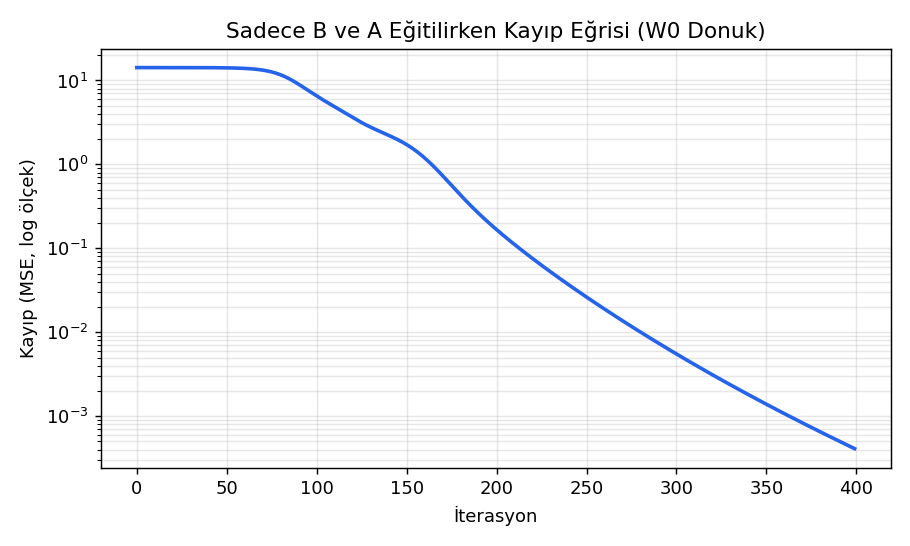

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

d_in, d_out = 64, 64
r_true = 4          # gerçek (gizli) düşük-rank yapısı
r = 4                # LoRA'nın kullanacağı rank
alpha = 8
scale = alpha / r

# Donuk (frozen) taban ağırlık W0 -- gerçek bir LLM katmanını temsil eder
W0 = np.random.randn(d_in, d_out) * 0.1

# "Gizli" hedef güncelleme: görevin gerektirdiği, bilmediğimiz düşük-ranklı güncelleme
B_true = np.random.randn(d_in, r_true) * 0.5
A_true = np.random.randn(r_true, d_out) * 0.5
delta_W_true = B_true @ A_true
W_target = W0 + delta_W_true

X = np.random.randn(200, d_in)
Y_target = X @ W_target

# LoRA başlatma kuralı: B=0, A~küçük rastgele
B = np.zeros((d_in, r))
A = np.random.randn(r, d_out) * 0.01

lr = 0.05
n_iter = 400
losses = []

for it in range(n_iter):
    delta_W = scale * (B @ A)
    W_eff = W0 + delta_W              # W0 DONUK -- hiçbir zaman güncellenmiyor
    Y_pred = X @ W_eff

    diff = Y_pred - Y_target
    loss = np.mean(diff ** 2)
    losses.append(loss)

    dY = (2.0 / diff.size) * diff
    dW_eff = X.T @ dY
    d_delta = scale * dW_eff
    dB = d_delta @ A.T
    dA = B.T @ d_delta

    B -= lr * dB
    A -= lr * dA

    if it % 50 == 0 or it == n_iter - 1:
        print(f"  İterasyon {it:4d}  |  Kayıp (MSE): {loss:.6f}")

full_ft_params = d_in * d_out
lora_params = d_in * r + r * d_out

print()
print(f"Başlangıç kaybı : {losses[0]:.5f}")
print(f"Son kayıp       : {losses[-1]:.5f}")
print(f"Kayıp azalımı   : %{(1 - losses[-1]/losses[0]) * 100:.3f}")
print()
print(f"Tam ince-ayar (W tamamı) eğitilebilir parametre sayısı : {full_ft_params:>6d}")
print(f"LoRA (sadece B ve A)     eğitilebilir parametre sayısı : {lora_params:>6d}")
print(f"Parametre tasarrufu                                    : {full_ft_params / lora_params:.1f}x daha az")

plt.figure(figsize=(7, 4.2))
plt.plot(losses, color="#2563eb", linewidth=2)
plt.yscale("log")
plt.xlabel("İterasyon")
plt.ylabel("Kayıp (MSE, log ölçek)")
plt.title("Sadece B ve A Eğitilirken Kayıp Eğrisi (W0 Donuk)")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()


Gördüğünüz gibi, sadece **512 parametreyi** ($B$ ve $A$) eğiterek, kayıp 400 iterasyonda
**%99.99'dan fazla** azaldı ve model, gizli düşük-ranklı hedefe çok yakın yakınsadı — taban
ağırlık $W_0$'a **hiç dokunmadan**. Bu, LoRA'nın gerçek bir LLM'de yaptığının minyatür,
çerçevesi sadeleştirilmiş ama kavramsal olarak doğru bir simülasyonudur.

> 📌 **Not:** Gerçek bir LLM'de hedef güncelleme bu kadar "temiz" düşük-ranklı olmayabilir,
> ama ampirik olarak (LoRA makalesi ve sonraki çalışmalar) gösterilmiştir ki $r=8$-$64$
> aralığı çoğu görev için tam ince ayara çok yakın performans verir.


<a id="4"></a>
## 4. Hugging Face PEFT Kütüphanesi ile LoRA

Artık teoriyi gördük; şimdi gerçek bir transformer modeline Hugging Face'in **PEFT**
kütüphanesi ile nasıl LoRA uygulanacağını inceleyelim. Aşağıdaki kod hücreleri **Lambda
Labs GPU instance'ında** çalıştırılmak üzere yazılmıştır (bu defterde kasıtlı olarak
çalıştırılmamıştır).

### 4.1 LoRA Hangi Katmanlara Uygulanır?

Modern transformer mimarilerinde (Llama, Mistral, Qwen vb.) LoRA tipik olarak şu doğrusal
(linear) katmanlara uygulanır:

- **Dikkat (attention) projeksiyonları:** `q_proj`, `k_proj`, `v_proj`, `o_proj`
- **MLP / Feed-forward projeksiyonları:** `gate_proj`, `up_proj`, `down_proj`

Aşağıdaki diyagram, bir transformer bloğunda bu katmanların nerede yer aldığını ve her
birine küçük bir LoRA adaptörünün (yeşil etiket) nasıl "iliştirildiğini" gösteriyor —
gri kutular donuk (frozen), yeşil etiketler eğitilebilir LoRA parçalarıdır:


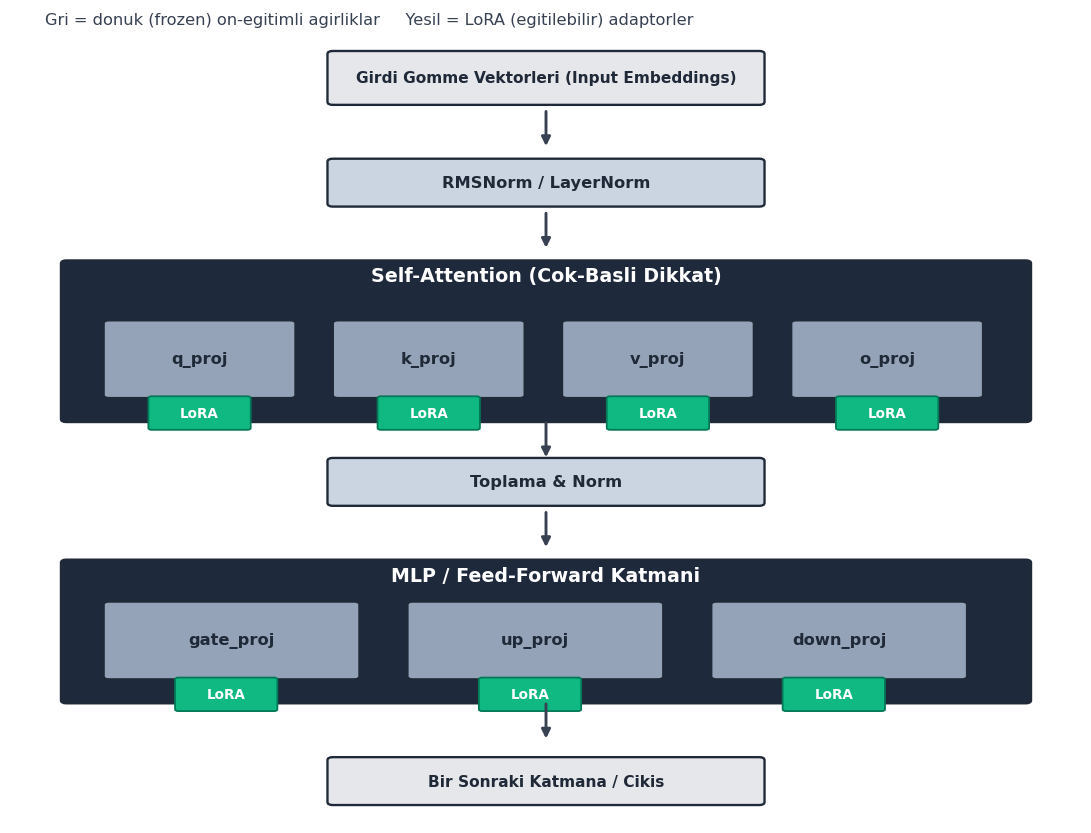

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis("off")

def kutu(x, y, w, h, renk, metin, fontsize=9.5, textcolor="white", edge="#1f2937"):
    p = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                                 facecolor=renk, edgecolor=edge, linewidth=1.3)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, metin, ha="center", va="center", fontsize=fontsize,
            fontweight="bold", color=textcolor)

def ok(x, y1, y2):
    # Ok daima YUKARIDAN (y2, buyuk deger) AsAGIYA (y1, kucuk deger) dogru cizilir
    ax.annotate("", xy=(x, y1), xytext=(x, y2),
                arrowprops=dict(arrowstyle="-|>", color="#374151", linewidth=1.6))

def lora_etiket(x, y):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), 0.9, 0.5, boxstyle="round,pad=0.03",
                                          facecolor="#10b981", edgecolor="#047857", linewidth=1))
    ax.text(x + 0.45, y + 0.25, "LoRA", ha="center", va="center", fontsize=7.5, fontweight="bold", color="white")

# Giris
kutu(3, 12, 4, 0.8, "#e5e7eb", "Girdi Gomme Vektorleri (Input Embeddings)", fontsize=8.5, textcolor="#1f2937")
ok(5, 11.2, 11.9)

# LayerNorm 1
kutu(3, 10.3, 4, 0.7, "#cbd5e1", "RMSNorm / LayerNorm", fontsize=9, textcolor="#1f2937")
ok(5, 9.5, 10.2)

# Self-Attention blogu
kutu(0.5, 6.7, 9, 2.6, "#1e293b", "", fontsize=1)
ax.text(5, 9.0, "Self-Attention (Cok-Basli Dikkat)", ha="center", fontsize=10.5, fontweight="bold", color="white")
isimler = ["q_proj", "k_proj", "v_proj", "o_proj"]
for i, isim in enumerate(isimler):
    x0 = 0.9 + i*2.15
    kutu(x0, 7.1, 1.7, 1.2, "#94a3b8", isim, fontsize=9, textcolor="#1f2937")
    lora_etiket(x0 + 0.4, 6.55)

ok(5, 6.0, 6.7)

# Add & Norm
kutu(3, 5.3, 4, 0.7, "#cbd5e1", "Toplama & Norm", fontsize=9, textcolor="#1f2937")
ok(5, 4.5, 5.2)

# MLP blogu
kutu(0.5, 2.0, 9, 2.3, "#1e293b", "", fontsize=1)
ax.text(5, 4.0, "MLP / Feed-Forward Katmani", ha="center", fontsize=10.5, fontweight="bold", color="white")
isimler2 = ["gate_proj", "up_proj", "down_proj"]
for i, isim in enumerate(isimler2):
    x0 = 0.9 + i*2.85
    kutu(x0, 2.4, 2.3, 1.2, "#94a3b8", isim, fontsize=9, textcolor="#1f2937")
    lora_etiket(x0 + 0.65, 1.85)

ok(5, 1.3, 2.0)

# Cikis
kutu(3, 0.3, 4, 0.7, "#e5e7eb", "Bir Sonraki Katmana / Cikis", fontsize=8.5, textcolor="#1f2937")

ax.text(0.3, 13.3, "Gri = donuk (frozen) on-egitimli agirliklar     Yesil = LoRA (egitilebilir) adaptorler",
        fontsize=9, color="#374151")

plt.tight_layout()
plt.show()


### 4.2 Model ve Tokenizer'ı Yükleme


In [ ]:
# Lambda Labs GPU instance'ında çalıştırın:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "meta-llama/Llama-3.1-8B-Instruct"  # örnek; istediğiniz açık modelle değiştirin

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,   # LoRA (QLoRA değil) için tipik tercih: bf16
    device_map="auto",
)


### 4.3 LoRA Konfigürasyonu ve Modele Uygulanması

`LoraConfig`, LoRA'nın nasıl uygulanacağını tanımlar: rank ($r$), ölçekleme ($\alpha$),
dropout, hedef modüller ve görev tipi.


In [ ]:
# Lambda Labs GPU instance'ında çalıştırın:
from peft import LoraConfig, get_peft_model, TaskType

peft_config = LoraConfig(
    r=32,                       # rank -- bkz. bölüm 4.4 için seçim rehberi
    lora_alpha=16,               # ölçekleme katsayısı (yaygın kural: alpha = r veya r/2)
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()
# Örnek çıktı:
# trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


### 4.4 Rank ($r$) ve Alpha Seçimi İçin Rehber

| Rank ($r$) | Eğitilebilir Parametre | Ne Zaman Kullanılır |
|---|---|---|
| 4-8 | Çok düşük | Basit görevler, stil/format adaptasyonu, çok az veri |
| 16-32 | Orta (yaygın varsayılan) | Çoğu görev için iyi denge — **genel tavsiye** |
| 64-128 | Yüksek | Karmaşık görevler, alan-spesifik bilgi aktarımı, büyük veri seti |
| 256+ | Çok yüksek | Tam ince ayara yaklaşmaya çalışırken (ekstra fayda azalır) |

**Alpha** genellikle $r$'ye eşit veya $r$'nin iki katı seçilir (örn. $r=16, \alpha=16$ veya
$r=16, \alpha=32$); $\alpha/r$ oranı sabit tutulduğunda farklı rank'ler arasında öğrenme
davranışı daha öngörülebilir olur.

Aşağıdaki diyagram, rank arttıkça eğitilebilir parametre sayısının (kırmızı, doğrusal) ve
**temsili/gösterge niteliğindeki** görev performansının (yeşil, doyma eğilimli) nasıl
değiştiğini özetliyor — gölgeli bölge, pratikte en sık kullanılan "tatlı nokta" aralığını
gösteriyor:


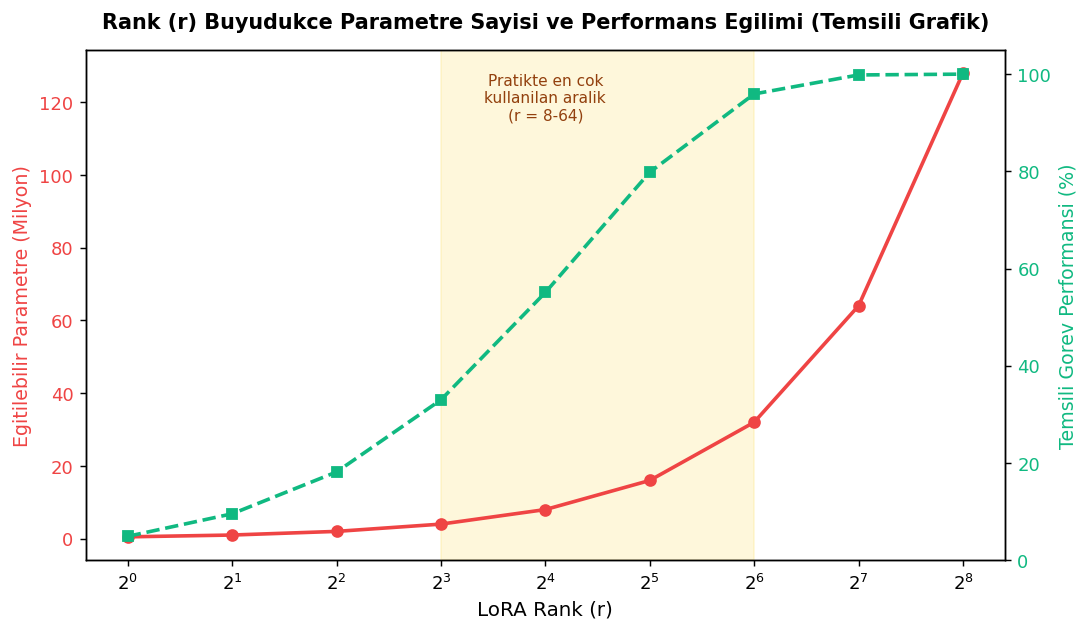

In [6]:
import matplotlib.pyplot as plt
import numpy as np

r_degerleri = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])
egitilebilir_milyon = r_degerleri * 0.5      # basitlestirilmis ornek olcekleme
gorev_performansi = 100 * (1 - np.exp(-r_degerleri/20))  # kavramsal/temsili dogrusal-doygunluk egrisi

fig, ax1 = plt.subplots(figsize=(8.5, 5))
renk1 = "#ef4444"
ax1.set_xlabel("LoRA Rank (r)", fontsize=11)
ax1.set_ylabel("Egitilebilir Parametre (Milyon)", color=renk1, fontsize=10.5)
ax1.plot(r_degerleri, egitilebilir_milyon, marker="o", color=renk1, linewidth=2)
ax1.tick_params(axis="y", labelcolor=renk1)
ax1.set_xscale("log", base=2)

ax2 = ax1.twinx()
renk2 = "#10b981"
ax2.set_ylabel("Temsili Gorev Performansi (%)", color=renk2, fontsize=10.5)
ax2.plot(r_degerleri, gorev_performansi, marker="s", color=renk2, linewidth=2, linestyle="--")
ax2.tick_params(axis="y", labelcolor=renk2)
ax2.set_ylim(0, 105)

ax1.axvspan(8, 64, color="#fde68a", alpha=0.3)
ax1.text(16, max(egitilebilir_milyon)*0.9, "Pratikte en cok\nkullanilan aralik\n(r = 8-64)",
         fontsize=8.5, ha="center", color="#92400e")

plt.title("Rank (r) Buyudukce Parametre Sayisi ve Performans Egilimi (Temsili Grafik)",
          fontsize=11.5, fontweight="bold", pad=12)
fig.tight_layout()
plt.show()


> 📌 Yukarıdaki grafikteki performans eğrisi **gerçek bir benchmark verisi değildir** —
> rank arttıkça getirinin azalan-verim (diminishing returns) eğilimini göstermek amacıyla
> **temsili olarak** çizilmiştir. Kendi göreviniz için en iyi rank'i bulmak amacıyla küçük
> bir grid-search (örn. $r \in \{8, 16, 32, 64\}$) yapmanız önerilir.


<a id="5"></a>
## 5. QLoRA: Kuantize Edilmiş LoRA

**QLoRA** (Dettmers ve arkadaşları, 2023, arXiv:2305.14314), LoRA'nın bellek verimliliğini
bir adım öteye taşır: taban model ağırlıkları **4-bit'e kuantize edilerek** belleğe yüklenir,
LoRA adaptörleri ise normal hassasiyette (bf16) eğitilir. Bu sayede, örneğin bir 70B modeli
**tek bir 48GB GPU'da** ince ayar yapmak mümkün hale gelir.

### 5.1 Neden 4-bit? Hassasiyet (Precision) Karşılaştırması

Aşağıdaki grafik, farklı sayısal hassasiyet formatlarının parametre başına bit sayısını ve
7B'lik bir model için sonuçtaki toplam bellek miktarını gösteriyor:


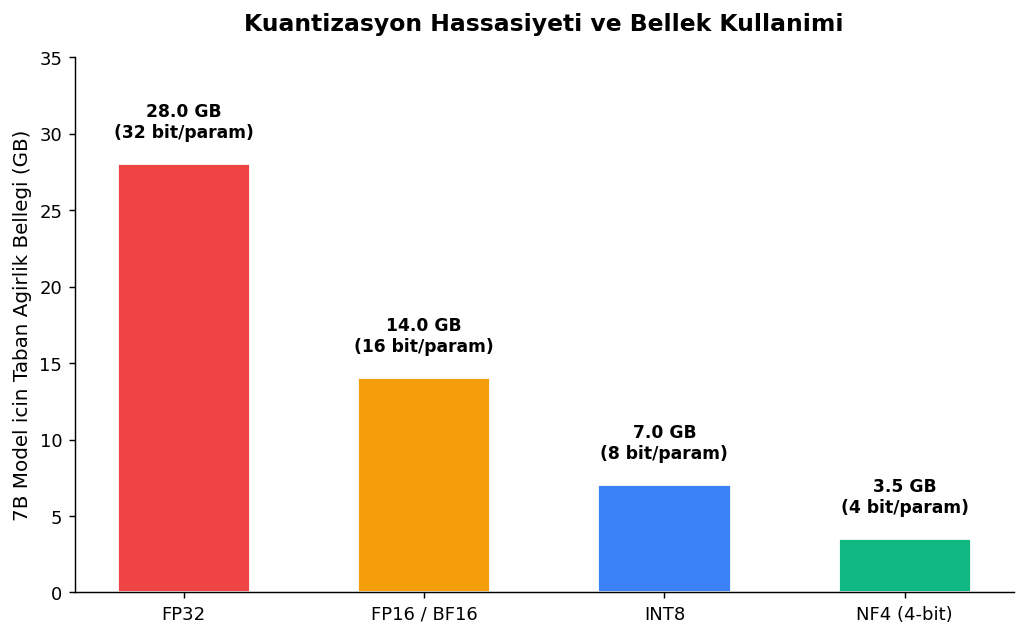

In [7]:
import matplotlib.pyplot as plt

hassasiyetler = ["FP32", "FP16 / BF16", "INT8", "NF4 (4-bit)"]
bit_sayisi = [32, 16, 8, 4]
yedi_b_gb = [b/8 * 7_000_000_000 / 1e9 for b in bit_sayisi]
renkler = ["#ef4444", "#f59e0b", "#3b82f6", "#10b981"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(hassasiyetler, yedi_b_gb, color=renkler, width=0.55, edgecolor="white")

for bar, gb, bit in zip(bars, yedi_b_gb, bit_sayisi):
    ax.text(bar.get_x() + bar.get_width()/2, gb + 1.5, f"{gb:.1f} GB\n({bit} bit/param)",
            ha="center", va="bottom", fontsize=9.5, fontweight="bold")

ax.set_ylabel("7B Model icin Taban Agirlik Bellegi (GB)", fontsize=11)
ax.set_title("Kuantizasyon Hassasiyeti ve Bellek Kullanimi", fontsize=13, fontweight="bold", pad=15)
ax.set_ylim(0, 35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### 5.2 QLoRA'nın Üç Temel Yeniliği

1. **NF4 (4-bit NormalFloat):** Standart 4-bit kuantizasyondan farklı olarak, normal
   dağılıma sahip ağırlıklar için **bilgi-teorik açıdan optimal** olacak şekilde tasarlanmış
   özel bir veri tipi. Ağırlıkların gerçek dağılımına daha iyi uyduğu için, eşdeğer bit
   sayısında daha az bilgi kaybı yaşanır.
2. **Çifte Kuantizasyon (Double Quantization):** Kuantizasyon sabitlerinin (her blok için
   saklanan scale/zero-point değerleri) kendisi de kuantize edilir — bu, parametre başına
   ek ~0.4 bit tasarruf sağlar (büyük modellerde toplamda gigabaytlarca bellek anlamına
   gelebilir).
3. **Sayfalanmış Optimizörler (Paged Optimizers):** NVIDIA'nın birleşik bellek (unified
   memory) özelliğini kullanarak, GPU belleği dolduğunda optimizer durumlarını otomatik
   olarak CPU belleğine "sayfalar" — bu, ani bellek artışlarında (gradyan checkpointing
   sırasında oluşan tepe noktalarında) OOM (out-of-memory) hatalarını önler.

Tüm bu parçaların nasıl bir araya geldiğini özetleyen tam QLoRA boru hattı (pipeline):


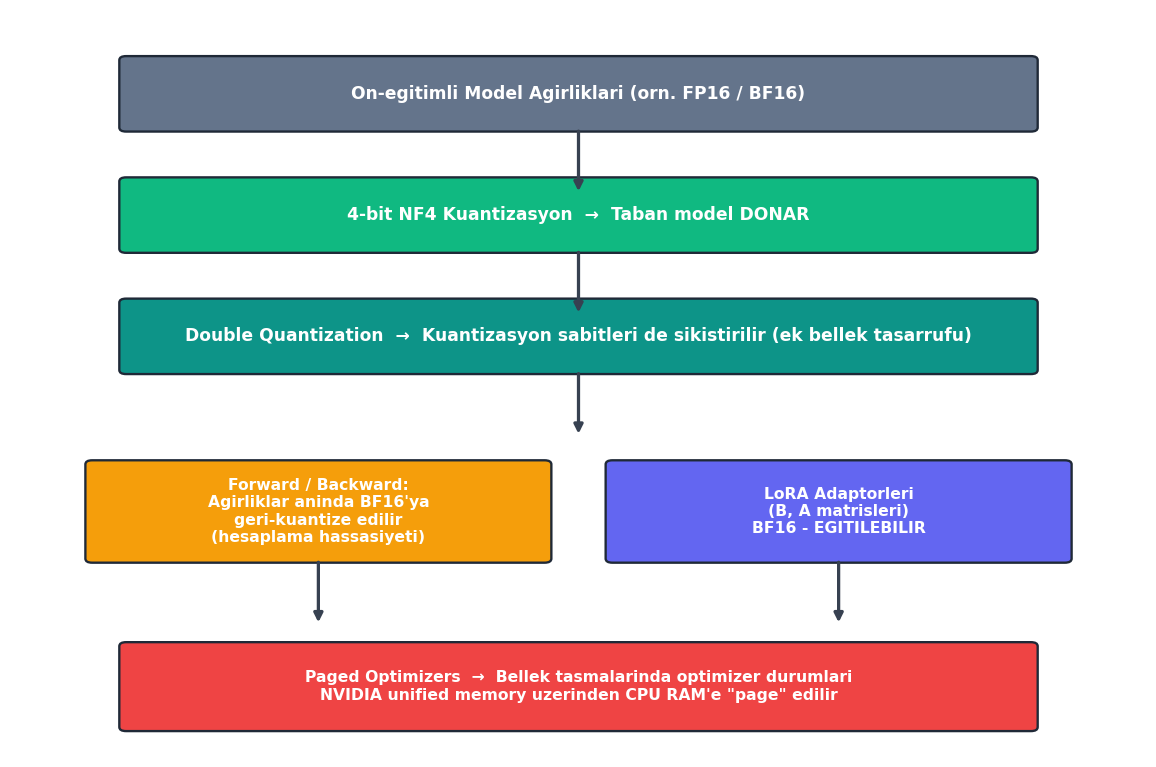

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis("off")

def kutu(x, y, w, h, renk, metin, fontsize=9.5, textcolor="white"):
    p = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.06",
                                 facecolor=renk, edgecolor="#1f2937", linewidth=1.3)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, metin, ha="center", va="center", fontsize=fontsize,
            fontweight="bold", color=textcolor)

def ok(x, y1, y2):
    # Ok daima YUKARIDAN (y2, buyuk deger) AsAGIYA (y1, kucuk deger) dogru cizilir
    ax.annotate("", xy=(x, y1), xytext=(x, y2),
                arrowprops=dict(arrowstyle="-|>", color="#374151", linewidth=1.8))

kutu(1, 9.3, 8, 1.0, "#64748b", "On-egitimli Model Agirliklari (orn. FP16 / BF16)")
ok(5, 8.3, 9.3)

kutu(1, 7.5, 8, 1.0, "#10b981", "4-bit NF4 Kuantizasyon  →  Taban model DONAR")
ok(5, 6.5, 7.5)

kutu(1, 5.7, 8, 1.0, "#0d9488", "Double Quantization  →  Kuantizasyon sabitleri de sikistirilir (ek bellek tasarrufu)")
ok(5, 4.7, 5.7)

kutu(0.7, 2.9, 4.0, 1.4, "#f59e0b", "Forward / Backward:\nAgirliklar aninda BF16'ya\ngeri-kuantize edilir\n(hesaplama hassasiyeti)", fontsize=8.7)
kutu(5.3, 2.9, 4.0, 1.4, "#6366f1", "LoRA Adaptorleri\n(B, A matrisleri)\nBF16 - EGITILEBILIR", fontsize=8.7)

ok(2.7, 1.9, 2.9)
ok(7.3, 1.9, 2.9)

kutu(1, 0.4, 8, 1.2, "#ef4444", "Paged Optimizers  →  Bellek tasmalarinda optimizer durumlari\nNVIDIA unified memory uzerinden CPU RAM'e \"page\" edilir", fontsize=8.7)

plt.tight_layout()
plt.show()


### 5.3 QLoRA Kurulumu: BitsAndBytesConfig


In [ ]:
# Lambda Labs GPU instance'ında çalıştırın:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

model_id = "meta-llama/Llama-3.1-70B-Instruct"  # QLoRA, çok daha büyük modelleri mümkün kılar

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",                    # NF4: normal dağılım için optimize edilmiş 4-bit
    bnb_4bit_compute_dtype=torch.bfloat16,         # hesaplamalar bf16'ya "dequantize" edilerek yapılır
    bnb_4bit_use_double_quant=True,                # çifte kuantizasyon -- ek bellek tasarrufu
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
)

# Kuantize edilmiş model üzerinde k-bit eğitimi için gerekli hazırlık
# (gradyan checkpointing'i etkinleştirir, bazı katmanları fp32'ye çevirir vb.)
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=64,                         # QLoRA'da genellikle biraz daha yüksek rank tercih edilir
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()


> ⚠️ **Önemli kısıtlama:** `bitsandbytes`, CUDA gerektirir — yalnızca NVIDIA GPU'larda
> çalışır, bu yüzden QLoRA hücreleri yalnızca gerçek bir GPU instance'ında (Lambda Labs gibi)
> çalıştırılabilir. Ayrıca, **kuantize edilmiş bir modelin LoRA adaptörleri, taban model
> 4-bit'teyken doğrudan birleştirilemez** (bkz. Bölüm 7) — bu kısıtlamayı aklınızda tutun.


<a id="6"></a>
## 6. Eğitim: TRL SFTTrainer ile Uçtan Uca Fine-Tuning

Hugging Face'in **TRL** (Transformer Reinforcement Learning) kütüphanesi, denetimli ince
ayar (Supervised Fine-Tuning, SFT) için `SFTTrainer` sınıfını sağlar. Bu sınıf, PEFT
konfigürasyonunu doğrudan kabul eder, böylece LoRA/QLoRA ile eğitim tek bir akışta birleşir.

### 6.1 Veri Kümesinin Yüklenmesi

Türkçe bir örnek için `merve/turkish_instructions` (Alpaca tarzı talimat veri kümesinin
Türkçe çevirisi, ~51K örnek) veya İngilizce için TRL'nin resmi örnek veri kümesi olan
`trl-lib/Capybara` kullanılabilir:


In [ ]:
# Lambda Labs GPU instance'ında çalıştırın:
from datasets import load_dataset

# Türkçe örnek:
dataset = load_dataset("merve/turkish_instructions", split="train")

# Alternatif - İngilizce, TRL'nin resmi örnek veri kümesi:
# dataset = load_dataset("trl-lib/Capybara", split="train")

print(dataset)
print(dataset[0])


### 6.2 SFTConfig ve SFTTrainer ile Eğitim

`SFTConfig`, standart `TrainingArguments`'ı genişletir (öğrenme oranı, batch boyutu, kayıt
adımları vb. + SFT'ye özel ayarlar: `max_seq_length`, `packing` gibi).


In [ ]:
# Lambda Labs GPU instance'ında çalıştırın:
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir="./qlora-output",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,      # etkin batch boyutu = 4*4 = 16
    learning_rate=2e-4,                  # LoRA için tipik öğrenme oranı (tam ince ayardan yüksek)
    bf16=True,
    logging_steps=10,
    save_strategy="epoch",
    max_seq_length=2048,
    gradient_checkpointing=True,         # bellek tasarrufu (bkz. Bölüm 8)
    report_to="none",                    # isterseniz "wandb" yapabilirsiniz
)

trainer = SFTTrainer(
    model=model,                # Bölüm 4 veya 5'te LoRA/QLoRA uygulanmış model
    args=training_args,
    train_dataset=dataset,
    peft_config=peft_config,    # SFTTrainer, PEFT config'i doğrudan kabul eder
)

trainer.train()

trainer.save_model("./qlora-output/final")


> 📌 **Öğrenme oranı notu:** LoRA/QLoRA ile eğitilen parametre sayısı çok küçük olduğu için,
> tipik öğrenme oranları ($1\text{e-}4$ - $3\text{e-}4$) tam ince ayardakinden ($1\text{e-}5$ -
> $5\text{e-}5$) genellikle **5-10 kat daha yüksektir**.

### 6.3 Eğitim Sırasında Checkpoint Kaydetme

`save_strategy="epoch"` ile her epoch sonunda otomatik checkpoint alınır. Uzun eğitimlerde,
Lambda Labs instance'ının kalıcı disk alanına (persistent storage) kaydetmeyi unutmayın —
bkz. Bölüm 8.4.


<a id="7"></a>
## 7. Adaptör Birleştirme ve Inference

Eğitim bittikten sonra, LoRA adaptörlerini kullanmanın iki yolu vardır: **(a)** adaptörleri
taban modelden ayrı tutup çalışma zamanında birleştirmek, veya **(b)** adaptörleri taban
ağırlıklara kalıcı olarak "birleştirip" (merge) tek bir model elde etmek.

### 7.1 Adaptörün Ayrı Tutularak Yüklenmesi (Hafif, Esnek)


In [ ]:
# Lambda Labs GPU instance'ında çalıştırın:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

base_model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.1-8B-Instruct", torch_dtype=torch.bfloat16, device_map="auto"
)
model = PeftModel.from_pretrained(base_model, "./qlora-output/final")
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

inputs = tokenizer("Türkiye'nin başkenti", return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=50)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Bu yaklaşımın avantajı: aynı taban modeli belleğe bir kez yükleyip, **farklı görevler için
eğitilmiş birden çok küçük adaptörü** (her biri genellikle yalnızca onlarca/yüzlerce MB)
gerektiğinde takıp çıkarabilirsiniz.

### 7.2 Adaptörü Taban Modele Kalıcı Olarak Birleştirme (Merge)

Eğer tek, bağımsız bir model dosyası istiyorsanız, `merge_and_unload()` kullanılır:


In [ ]:
# Lambda Labs GPU instance'ında çalıştırın:
merged_model = model.merge_and_unload()
merged_model.save_pretrained("./merged-model")
tokenizer.save_pretrained("./merged-model")


> ⚠️ **Kritik kısıtlama (QLoRA için):** `merge_and_unload()`, taban model **4-bit kuantize**
> haldeyken doğrudan çalışmaz/desteklenmez. QLoRA ile eğittiğiniz adaptörleri birleştirmek
> isterseniz, önce taban modeli **fp16/bf16 olarak (kuantize etmeden) yeniden yükleyip**,
> adaptörü o model üzerine uygulayıp birleştirmeniz gerekir:

```python
# 1. Taban modeli bu kez normal hassasiyette (kuantize ETMEDEN) yükleyin
base_model_fp16 = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.1-70B-Instruct", torch_dtype=torch.bfloat16, device_map="auto"
)
# 2. Adaptörü bu fp16 model üzerine uygulayın
model_for_merge = PeftModel.from_pretrained(base_model_fp16, "./qlora-output/final")
# 3. Şimdi birleştirme çalışır
merged_model = model_for_merge.merge_and_unload()
```


<a id="8"></a>
## 8. Lambda Labs İpuçları ve Çoklu-GPU Eğitimi

### 8.1 Çoklu-GPU: Accelerate ile DDP / FSDP

Lambda Labs'te 4x veya 8x GPU'lu instance'lar kiralayabilirsiniz. Çoklu-GPU eğitimi için
Hugging Face `accelerate` kütüphanesi kullanılır:


In [ ]:
# Terminal'de (Lambda Labs instance'ında), interaktif konfigürasyon sihirbazı:
# accelerate config

# Ardından eğitim betiğini şu şekilde başlatın:
# accelerate launch --num_processes=4 train.py


- **DDP (Distributed Data Parallel):** Model her GPU'ya tamamen kopyalanır, veri GPU'lar
  arasında bölünür. Model tek bir GPU'ya sığıyorsa (QLoRA ile genellikle sığar) en basit
  ve hızlı seçenektir.
- **FSDP (Fully Sharded Data Parallel) + QLoRA:** Model tek bir GPU'ya sığmıyorsa (çok büyük
  modeller), model parçalarını (shard) GPU'lar arasında dağıtır. `FSDP + QLoRA` kombinasyonu,
  topluluk tarafından (Answer.AI ve Hugging Face ekiplerinin çalışmalarıyla) 70B'lik
  modelleri tüketici sınıfı GPU kümeleri üzerinde eğitmeyi mümkün kılan popüler bir yöntem
  haline gelmiştir.

### 8.2 Gradyan Checkpointing

Bellek kullanımını azaltmak için (hesaplama süresinden ödün vererek) ara aktivasyonları
saklamak yerine geriye yayılım (backprop) sırasında yeniden hesaplar:

```python
model.gradient_checkpointing_enable()
# veya SFTConfig içinde: gradient_checkpointing=True
```

### 8.3 Gradient Accumulation

GPU belleği büyük bir batch boyutuna yetmiyorsa, küçük batch'lerle birden çok ileri/geri
geçiş yapıp gradyanları biriktirerek büyük bir "etkin batch boyutu" simüle edilir:

```python
per_device_train_batch_size=4, gradient_accumulation_steps=8  # etkin batch = 32
```

### 8.4 Kalıcı Depolama (Persistent Storage)

Lambda Labs instance'ları **durdurulduğunda (terminate)** yerel disk genellikle silinir.
Önemli checkpoint'leri ve veri kümelerini kalıcı tutmak için:

- Lambda Labs'in **kalıcı depolama (persistent storage)** seçeneğini (varsa bölgenizde)
  kullanın ve checkpoint'leri oraya kaydedin.
- Alternatif olarak, düzenli aralıklarla checkpoint'leri harici depolamaya (S3, Hugging Face
  Hub `push_to_hub=True` vb.) yükleyin.

### 8.5 İzleme (Monitoring)

```bash
# Terminal'de GPU kullanımını canlı izlemek için:
watch -n 1 nvidia-smi
```

Eğitim metriklerini (kayıp, öğrenme oranı vb.) görselleştirmek için `SFTConfig`'te
`report_to="wandb"` ayarlayıp [Weights & Biases](https://wandb.ai) entegrasyonunu
kullanabilirsiniz.


<a id="9"></a>
## 9. Karar Rehberi: Tam İnce Ayar mı, LoRA mı, QLoRA mı?

| Kriter | Tam İnce Ayar | LoRA | QLoRA |
|---|---|---|---|
| **GPU bellek ihtiyacı** | Çok yüksek (7B için ~112GB) | Orta (7B için ~15GB) | Düşük (7B için ~5GB) |
| **Eğitim hızı** | En yavaş (tüm parametreler güncellenir) | Hızlı | Biraz daha yavaş (kuantizasyon/dequantize ek yükü) |
| **Nihai kalite** | Teorik üst sınır | Çoğu görevde tam ince ayara çok yakın | LoRA'ya çok yakın, marjinal ek kalite kaybı olabilir |
| **Donanım maliyeti** | Çok yüksek (çoklu A100/H100) | Orta (tek A100 veya hatta tek tüketici GPU) | Düşük (tek tüketici GPU bile yeterli olabilir) |
| **Birden çok görev/adaptör** | Her görev için tam model kopyası gerekir | Tek taban + küçük adaptörler (MB seviyesi) | Tek taban + küçük adaptörler |
| **Ne zaman tercih edilir** | Bütçe/donanım sınırsız, maksimum performans kritik | En yaygın, dengeli seçim — **çoğu durumda önerilir** | Donanım çok kısıtlı veya çok büyük model (30B+) küçük GPU'da denenecek |

**Genel pratik öneri:** Önce **QLoRA ile** küçük bir GPU'da hızlıca prototip oluşturun;
sonuçlar umut verici ve daha fazla bütçeniz varsa, daha hızlı eğitim için **LoRA (bf16)**'ya
geçin. Tam ince ayarı genellikle yalnızca çok büyük veri kümeleri ve maksimum performansın
kritik olduğu, donanım kısıtının olmadığı senaryolarda düşünün.


<a id="10"></a>
## 10. Kaynaklar

### Akademik Makaleler
- Hu, E. J. ve ark. (2021). **LoRA: Low-Rank Adaptation of Large Language Models.**
  [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
- Dettmers, T. ve ark. (2023). **QLoRA: Efficient Finetuning of Quantized LLMs.**
  [arXiv:2305.14314](https://arxiv.org/abs/2305.14314)

### Resmi Dokümantasyon
- Hugging Face **PEFT** kütüphanesi: [huggingface.co/docs/peft](https://huggingface.co/docs/peft)
- Hugging Face **TRL** kütüphanesi: [huggingface.co/docs/trl](https://huggingface.co/docs/trl)
- **bitsandbytes**: [github.com/bitsandbytes-foundation/bitsandbytes](https://github.com/bitsandbytes-foundation/bitsandbytes)

### Lambda Labs
- Fiyatlandırma (güncel rakamlar için kontrol edin): [lambda.ai/pricing](https://lambda.ai/pricing)
- Dokümantasyon: [docs.lambda.ai](https://docs.lambda.ai)

### Veri Kümeleri (Bu Defterde Kullanılan Örnekler)
- `merve/turkish_instructions` — Türkçe talimat veri kümesi (Alpaca tarzı, ~51K örnek)
- `trl-lib/Capybara` — TRL'nin resmi İngilizce SFT örnek veri kümesi

---

<p style="text-align:center; color:#888;">Bu defter eğitim amaçlıdır. Üretim (production)
kullanımına geçmeden önce her zaman kendi veri kümeniz ve donanımınızla küçük ölçekli
testler yapın, ve Lambda Labs fiyatlandırmasını güncel sayfadan teyit edin.</p>
